In [3]:
import torch
import torch.nn as nn
import sys
from pathlib import Path
!git clone https://github.com/MuhammadJamall/Deepfake_Detection /content/repo

fatal: destination path '/content/repo' already exists and is not an empty directory.


In [6]:
import torch
import torch.nn as nn
import sys
from pathlib import Path

sys.path.insert(0, '/content/repo')  # ✅ CORRECT - parent folder, not src/

from src.dataset import get_dataloaders
from src.models import create_model
from src.training import Trainer
from src.evaluation import Evaluator
from src.utils import check_gpu, get_device

# Check GPU
device = get_device()
check_gpu()

print("✓ All imports successful")


GPU INFORMATION
✓ GPU Available: YES
  Device: Tesla T4
  Total Memory: 15.64 GB
  PyTorch Version: 2.10.0+cu128
  CUDA Version: 12.8

✓ All imports successful


In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Create directories
Path('/content/repo/results/plots').mkdir(parents=True, exist_ok=True)
Path('/content/repo/results/models').mkdir(parents=True, exist_ok=True)

print("✓ Google Drive mounted")
print("✓ Directories created")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ Directories created


In [8]:
# Download and extract dataset
!kaggle datasets download -d fatimahirshad/faceforensics-c32-frames-cropped-aligned -p /content/ --unzip

print("✓ Dataset downloaded")

Dataset URL: https://www.kaggle.com/datasets/fatimahirshad/faceforensics-c32-frames-cropped-aligned
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 210M/210M [00:03<00:00, 63.6MB/s]

✓ Dataset downloaded


In [9]:
print("\nLoading dataloaders...")

train_loader, val_loader, test_loader, class_to_idx = get_dataloaders(
    dataset_dir='/content/Frames(cropped+aligned)',
    batch_size=32,
    train_split=0.8,
    val_split=0.1,
    num_workers=2
)

idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

print(f"✓ Class names: {class_names}")
print(f"✓ Class to index: {class_to_idx}")


Loading dataloaders...

✓ Dataset loaded from: /content/Frames(cropped+aligned)
✓ Total images: 29944
✓ Number of classes: 6
✓ Classes: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'Original']

DATALOADER SPLIT
Training set: 23955 images (80%)
Validation set: 2994 images (10%)
Test set: 2995 images (10%)
Batch size: 32

✓ Class names: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'Original']
✓ Class to index: {'Deepfakes': 0, 'Face2Face': 1, 'FaceShifter': 2, 'FaceSwap': 3, 'NeuralTextures': 4, 'Original': 5}


In [10]:
import torch
from src.utils import get_device, check_gpu

# Get device and check GPU
device = get_device()
check_gpu()

print(f"✓ Device: {device}")


GPU INFORMATION
✓ GPU Available: YES
  Device: Tesla T4
  Total Memory: 15.64 GB
  PyTorch Version: 2.10.0+cu128
  CUDA Version: 12.8

✓ Device: cuda


In [11]:
print("\nCreating EfficientNet-B4 model...")

model = create_model('efficientnet_b4', num_classes=len(class_to_idx), pretrained=True)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model created: EfficientNet-B4")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Trainable parameters: {trainable_params:,}")


Creating EfficientNet-B4 model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 173MB/s]


✓ Model created: EfficientNet-B4
✓ Total parameters: 17,559,374
✓ Trainable parameters: 17,559,374


In [12]:
print("\nInitializing trainer...")

trainer = Trainer(model, device, model_name='efficientnet_b4')

print("✓ Trainer initialized")


# CELL 6: Train model (2-phase training)
print("\nStarting 2-phase training...")

# This will take time - grab a coffee! ☕
history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    phase1_epochs=3,
    save_path='/content/repo/results/models/'
)

print("\n✓ Training complete!")


Initializing trainer...
✓ Trainer initialized

Starting 2-phase training...

PHASE 1: Training Classifier Only (Backbone Frozen)

Phase 1 - Epoch 1/3


Validating: 100%|██████████| 94/94 [00:11<00:00,  8.53it/s, loss=1.7306, acc=0.3928]


Train Loss: 1.6470 | Train Acc: 0.3366
Val Loss: 1.5725 | Val Acc: 0.3928
Learning Rate: 0.000750
✓ Best model saved: /content/repo/results/models/efficientnet_b4_best.pth

Phase 1 - Epoch 2/3


Validating: 100%|██████████| 94/94 [00:11<00:00,  8.00it/s, loss=1.7004, acc=0.4205]


Train Loss: 1.5484 | Train Acc: 0.3894
Val Loss: 1.5206 | Val Acc: 0.4205
Learning Rate: 0.000250
✓ Best model saved: /content/repo/results/models/efficientnet_b4_best.pth

Phase 1 - Epoch 3/3


...

Train Loss: 0.2520 | Train Acc: 0.9075
Val Loss: 0.1518 | Val Acc: 0.9452
Learning Rate: 0.000007
✓ Best model saved: /content/repo/results/models/efficientnet_b4_best.pth

Phase 2 - Epoch 14/15


Validating: 100%|██████████| 94/94 [00:11<00:00,  8.19it/s, loss=0.2700, acc=0.9472]


Train Loss: 0.2419 | Train Acc: 0.9102
Val Loss: 0.1478 | Val Acc: 0.9472
Learning Rate: 0.000002
✓ Best model saved: /content/repo/results/models/efficientnet_b4_best.pth

Phase 2 - Epoch 15/15


Validating: 100%|██████████| 94/94 [00:11<00:00,  8.06it/s, loss=0.2720, acc=0.9472]

Train Loss: 0.2385 | Train Acc: 0.9105
Val Loss: 0.1487 | Val Acc: 0.9472
Learning Rate: 0.000000

Training Complete! Best Accuracy: 0.9472


✓ Training complete!


✓ Training history plot saved


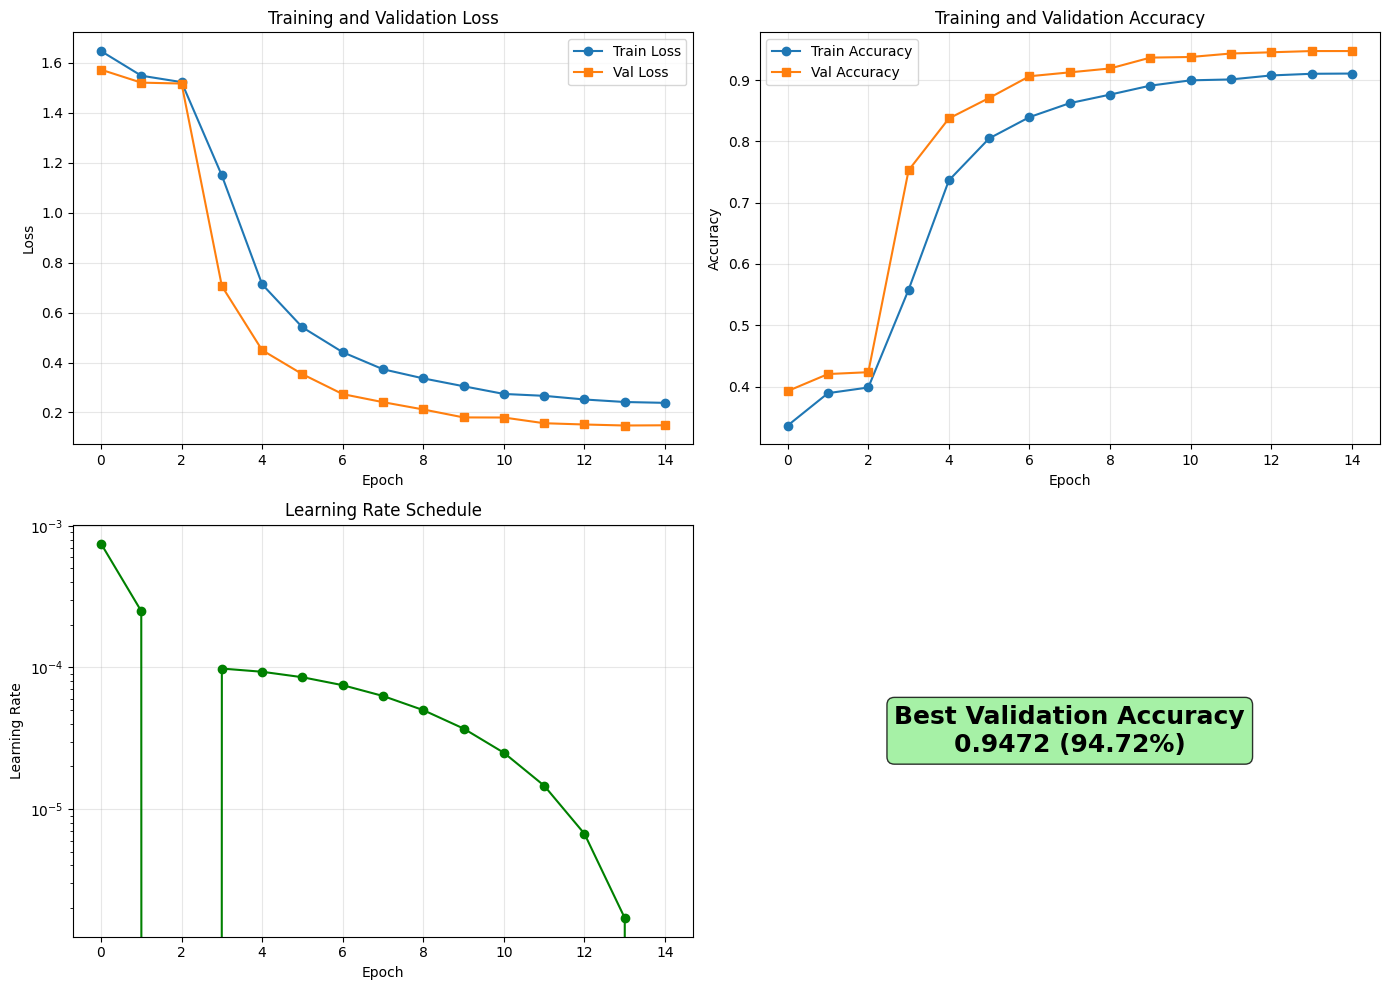

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Learning rate plot
axes[1, 0].plot(history['learning_rates'], marker='o', color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(alpha=0.3)

# Best accuracy
axes[1, 1].text(0.5, 0.5, f'Best Validation Accuracy\n{trainer.best_accuracy:.4f} ({trainer.best_accuracy*100:.2f}%)',
               ha='center', va='center', fontsize=18, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('/content/repo/results/plots/training_history.png', dpi=300, bbox_inches='tight')
print("✓ Training history plot saved")
plt.show()

In [14]:
print("\nLoading best model for evaluation...")

best_model_path = '/content/repo/results/models/efficientnet_b4_best.pth'
model.load_state_dict(torch.load(best_model_path))
model.to(device)

print(f"✓ Loaded best model from {best_model_path}")


Loading best model for evaluation...
✓ Loaded best model from /content/repo/results/models/efficientnet_b4_best.pth


In [15]:
print("\nEvaluating on test set...")

evaluator = Evaluator(model, device)
results = evaluator.evaluate(test_loader, class_names=class_names)


Evaluating on test set...


Evaluating: 100%|██████████| 94/94 [00:12<00:00,  7.59it/s]


In [16]:
evaluator.print_results(results)


TEST SET EVALUATION RESULTS
Overall Accuracy: 0.9472 (94.72%)

Confusion Matrix:
[[510   0   1   1   4   3]
 [  1 464   0   2   3   5]
 [  0   0 503   0   2   5]
 [  0   1   0 502   0   1]
 [  2   4   4   2 456  41]
 [  2   8   7   7  52 402]]

Classification Report:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Deepfakes            0.9903       0.9827       0.9865       519       
Face2Face            0.9727       0.9768       0.9748       475       
FaceShifter          0.9767       0.9863       0.9815       510       
FaceSwap             0.9767       0.9960       0.9862       504       
NeuralTextures       0.8820       0.8959       0.8889       509       
Original             0.8796       0.8410       0.8599       478       



In [18]:
print("\nGenerating evaluation plots...")

evaluator.plot_confusion_matrix(results, '/content/repo/results/plots/confusion_matrix.png')
evaluator.plot_roc_curve(results, '/content/repo/results/plots/roc_curve.png')
evaluator.plot_metrics_per_class(results, '/content/repo/results/plots/metrics_per_class.png')


Generating evaluation plots...
✓ Confusion matrix saved: /content/repo/results/plots/confusion_matrix.png
⚠ ROC curve only available for binary classification
✓ Metrics per class plot saved: /content/repo/results/plots/metrics_per_class.png


In [19]:
import json

metrics_summary = {
    'model': 'EfficientNet-B4',
    'accuracy': float(results['accuracy']),
    'roc_auc': float(results['roc_auc']) if results['roc_auc'] else None,
    'best_validation_accuracy': float(trainer.best_accuracy),
    'confusion_matrix': results['confusion_matrix'].tolist(),
    'classification_report': results['classification_report']
}

In [21]:

metrics_path = '/content/repo/results/metrics/efficientnet_b4_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(f"✓ Metrics saved to {metrics_path}")

✓ Metrics saved to /content/repo/results/metrics/efficientnet_b4_metrics.json


In [22]:
import shutil

drive_results_path = '/content/drive/MyDrive/FYP/week2_results'
Path(drive_results_path).mkdir(parents=True, exist_ok=True)

# Copy models
shutil.copy('/content/repo/results/models/efficientnet_b4_best.pth',
           f'{drive_results_path}/efficientnet_b4_best.pth')

# Copy plots
for plot_file in Path('/content/repo/results/plots').glob('*.png'):
    shutil.copy(plot_file, f'{drive_results_path}/{plot_file.name}')

# Copy metrics
shutil.copy(metrics_path, f'{drive_results_path}/efficientnet_b4_metrics.json')

print(f"✓ Results copied to Google Drive: {drive_results_path}")

✓ Results copied to Google Drive: /content/drive/MyDrive/FYP/week2_results


In [23]:
print("\n" + "="*70)
print("WEEK 2: EFFICIENTNET-B4 TRAINING - COMPLETE")
print("="*70)
print(f"Best Validation Accuracy: {trainer.best_accuracy:.4f} ({trainer.best_accuracy*100:.2f}%)")
print(f"Test Set Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
if results['roc_auc']:
    print(f"ROC-AUC Score: {results['roc_auc']:.4f}")
print("\nFiles saved:")
print(f"  ✓ Model: /content/repo/results/models/efficientnet_b4_best.pth")
print(f"  ✓ Plots: /content/repo/results/plots/")
print(f"  ✓ Metrics: {metrics_path}")
print("="*70)


WEEK 2: EFFICIENTNET-B4 TRAINING - COMPLETE
Best Validation Accuracy: 0.9472 (94.72%)
Test Set Accuracy: 0.9472 (94.72%)

Files saved:
  ✓ Model: /content/repo/results/models/efficientnet_b4_best.pth
  ✓ Plots: /content/repo/results/plots/
  ✓ Metrics: /content/repo/results/metrics/efficientnet_b4_metrics.json
